In [218]:
import sys
sys.path.append('/Users/kevinlaventure/python_code/python_module')

import numpy as np
import pandas as pd
from pricing_model import BSMModel
import matplotlib.pyplot as plt

# Set display options
pd.set_option('display.float_format', lambda x: f'{x:.6f}' if abs(x) < 1000 else f'{x:.2f}')

In [219]:
# ===== Monte Carlo Simulation Inputs (20 business days) =====
# Standard parameters
S = 100.0           # Spot price
r = 0.05            # Risk-free rate (5%)
g = 0.0             # Growth spread
q = 0.02            # Dividend yield (2%)
sigma = 0.20        # Volatility (20%)
K = 100.0           # Strike price (ATM)

# Time parameters
n_business_days = 20
n_steps = n_business_days  # 1 step per business day
T = n_business_days / 252  # Convert to years (252 business days per year)

# Monte Carlo parameters
n_paths = 1         # Single path as requested

print(f"=== Monte Carlo Simulation Parameters ===")
print(f"Spot Price (S): {S}")
print(f"Strike Price (K): {K}")
print(f"Risk-free Rate (r): {r:.4f}")
print(f"Growth Spread (g): {g:.4f}")
print(f"Dividend Yield (q): {q:.4f}")
print(f"Volatility (σ): {sigma:.4f}")
print(f"Time to Maturity: {T:.6f} years ({n_business_days} business days)")
print(f"Number of Steps: {n_steps}")
print(f"Number of Paths: {n_paths}")

=== Monte Carlo Simulation Parameters ===
Spot Price (S): 100.0
Strike Price (K): 100.0
Risk-free Rate (r): 0.0500
Growth Spread (g): 0.0000
Dividend Yield (q): 0.0200
Volatility (σ): 0.2000
Time to Maturity: 0.079365 years (20 business days)
Number of Steps: 20
Number of Paths: 1


In [220]:
# ===== Compute Monte Carlo Path =====
# Generate single Monte Carlo path (1 simulation with 20 steps)
S_paths = BSMModel.compute_montecarlo(
    S=S, 
    T=T, 
    r=r, 
    g=g, 
    q=q, 
    sigma=sigma, 
    n_steps=n_steps, 
    n_paths=n_paths,
    seed=True,
    seed_value=48
)

# Extract the single path and create time grid
spot_path = S_paths.iloc[:, 0].values
time_steps = np.arange(n_steps + 1)
time_years = time_steps / 252  # Convert to years

print(f"\n=== Monte Carlo Path (Single Simulation) ===")
print(f"Path shape: {S_paths.shape}")
print(f"\nSpot price at each business day:")
mc_df = pd.DataFrame({
    'Day': time_steps,
    'Time (Years)': time_years,
    'Spot Price': spot_path
})
print(mc_df.to_string(index=False))


=== Monte Carlo Path (Single Simulation) ===
Path shape: (21, 1)

Spot price at each business day:
 Day  Time (Years)  Spot Price
   0      0.000000  100.000000
   1      0.003968   98.759864
   2      0.007937   97.449411
   3      0.011905   96.672992
   4      0.015873   97.978543
   5      0.019841   97.788314
   6      0.023810   99.149067
   7      0.027778   96.594657
   8      0.031746   97.454954
   9      0.035714   99.536897
  10      0.039683   99.043797
  11      0.043651  101.990423
  12      0.047619  100.717902
  13      0.051587  100.014848
  14      0.055556   97.525845
  15      0.059524   97.080953
  16      0.063492   95.560262
  17      0.067460   98.053173
  18      0.071429   98.795251
  19      0.075397  100.758661
  20      0.079365  103.133295


In [221]:
# ===== Timeseries 1: 20 Business Day Option Daily PnL =====
# For each time step, price a 20 business day option (from that point forward)

timeseries_20bd = pd.DataFrame()
timeseries_20bd['Day'] = time_steps
timeseries_20bd['Time (Years)'] = time_years
timeseries_20bd['Spot Price'] = spot_path

prices_20bd = []

for i, current_spot in enumerate(spot_path):
    # Time remaining from this point
    T_remaining = (n_steps - i) / 252
    
    # Price the option at current spot and time
    option_result = BSMModel.compute_option(
        F=current_spot,
        K=K,
        T=T_remaining,
        r=r,
        sigma=sigma,
        option_type='put',
        compute_greeks=False
    )
    # Extract price from result dictionary
    option_price = option_result['price'] if isinstance(option_result, dict) else option_result
    prices_20bd.append(option_price)

prices_20bd = np.array(prices_20bd)
# Daily PnL: option_price_t - option_price_t-1
pnl_20bd = np.concatenate([[np.nan], np.diff(prices_20bd)])

timeseries_20bd['Option_Price_20BD'] = prices_20bd
timeseries_20bd['PnL_20BD'] = pnl_20bd

print("\n=== Timeseries 1: Daily PnL of 20 Business Day Option ===")
print(timeseries_20bd[['Day', 'Spot Price', 'Option_Price_20BD', 'PnL_20BD']].to_string(index=False))


=== Timeseries 1: Daily PnL of 20 Business Day Option ===
 Day  Spot Price  Option_Price_20BD  PnL_20BD
   0  100.000000           2.238587       NaN
   1   98.759864           2.842293  0.603706
   2   97.449411           3.608526  0.766234
   3   96.672992           4.104754  0.496227
   4   97.978543           3.151801 -0.952952
   5   97.788314           3.219847  0.068046
   6   99.149067           2.322142 -0.897705
   7   96.594657           3.967856  1.645715
   8   97.454954           3.274926 -0.692931
   9   99.536897           1.900668 -1.374257
  10   99.043797           2.101415  0.200747
  11  101.990423           0.728688 -1.372728
  12  100.717902           1.094607  0.365920
  13  100.014848           1.320599  0.225991
  14   97.525845           2.829550  1.508951
  15   97.080953           3.125357  0.295808
  16   95.560262           4.471148  1.345791
  17   98.053173           2.162170 -2.308978
  18   98.795251           1.465760 -0.696410
  19  100.758661     

In [222]:
# ===== Timeseries 2: 20 Business Day Option Slide Scenarios =====
# Daily slide scenarios for 20 business day option
slide_scenarios = [-0.01, -0.05, -0.10, -0.50]  # -1%, -5%, -10%, -50%

timeseries_20bd_slides = pd.DataFrame()
timeseries_20bd_slides['Day'] = time_steps
timeseries_20bd_slides['Time (Years)'] = time_years
timeseries_20bd_slides['Spot Price'] = spot_path

for slide in slide_scenarios:
    slide_pnl = []
    for i, current_spot in enumerate(spot_path):
        T_remaining = (n_steps - i) / 252
        
        # Price the option at the current spot
        result_base = BSMModel.compute_option(
            F=current_spot,
            K=K,
            T=T_remaining,
            r=r,
            sigma=sigma,
            option_type='put',
            compute_greeks=False
        )
        option_price_base = result_base['price'] if isinstance(result_base, dict) else result_base
        
        # Price the option at the slide level
        result_slide = BSMModel.compute_option(
            F=current_spot * (1 + slide),  # Bumped spot price
            K=K,
            T=T_remaining-(1/252),  # Assume slide happens at the end of the day, so reduce time by 1 day
            r=r,
            sigma=sigma,
            option_type='put',
            compute_greeks=False
        )
        option_price_slide = result_slide['price'] if isinstance(result_slide, dict) else result_slide
        
        # PnL from the slide (price difference)
        pnl = option_price_slide - option_price_base
        slide_pnl.append(pnl)
    
    slide_label = f'Slide_{int(slide*100):+d}pct'
    timeseries_20bd_slides[slide_label] = slide_pnl

print("\n=== Timeseries 2: Daily Slide Scenarios (-1%, -5%, -10%, -50%) for 20 Business Day Option ===")
print(timeseries_20bd_slides.to_string(index=False))


=== Timeseries 2: Daily Slide Scenarios (-1%, -5%, -10%, -50%) for 20 Business Day Option ===
 Day  Time (Years)  Spot Price  Slide_-1pct  Slide_-5pct  Slide_-10pct  Slide_-50pct
   0      0.000000  100.000000     0.467225     3.245457      7.778439     47.573276
   1      0.003968   98.759864     0.552363     3.607313      8.258415     47.597311
   2      0.007937   97.449411     0.642420     3.940617      8.654570     47.494107
   3      0.011905   96.672992     0.695779     4.120395      8.852414     47.395000
   4      0.015873   97.978543     0.616875     3.895319      8.639561     47.707335
   5      0.019841   97.788314     0.635591     3.976506      8.741941     47.744232
   6      0.023810   99.149067     0.535407     3.664198      8.424342     47.973426
   7      0.027778   96.594657     0.731714     4.286080      9.066613     47.611860
   8      0.031746   97.454954     0.681295     4.177850      8.989728     47.885815
   9      0.035714   99.536897     0.507576     3.66902

/Users/kevinlaventure/python_code/python_module/pricing_model.py:117: RuntimeWarning: invalid value encountered in sqrt
  d1 = (np.log(F / K) + (0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
/Users/kevinlaventure/python_code/python_module/pricing_model.py:118: RuntimeWarning: invalid value encountered in sqrt
  d2 = d1 - sigma * np.sqrt(T)
/Users/kevinlaventure/python_code/python_module/pricing_model.py:117: RuntimeWarning: invalid value encountered in sqrt
  d1 = (np.log(F / K) + (0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
/Users/kevinlaventure/python_code/python_module/pricing_model.py:118: RuntimeWarning: invalid value encountered in sqrt
  d2 = d1 - sigma * np.sqrt(T)
/Users/kevinlaventure/python_code/python_module/pricing_model.py:117: RuntimeWarning: invalid value encountered in sqrt
  d1 = (np.log(F / K) + (0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
/Users/kevinlaventure/python_code/python_module/pricing_model.py:118: RuntimeWarning: invalid value encountered in sqrt
  d2 

In [223]:
# ===== Timeseries 3: 1 Business Day Option Daily PnL =====
# For each time step, price a 1 business day option
# PnL = max(0, K - S_T) - premium (where S_T is spot at expiry next day)

timeseries_1bd = pd.DataFrame()
timeseries_1bd['Day'] = time_steps
timeseries_1bd['Time (Years)'] = time_years
timeseries_1bd['Spot Price'] = spot_path

prices_1bd = []
pnl_1bd = []

T_1bd = 1 / 252  # 1 business day in years

for i, current_spot in enumerate(spot_path):
    # Price a 1-day option at current spot
    option_result = BSMModel.compute_option(
        F=current_spot,
        K=current_spot,
        T=T_1bd,
        r=r,
        sigma=sigma,
        option_type='put',
        compute_greeks=False
    )
    # Extract price from result dictionary
    option_price = option_result['price'] if isinstance(option_result, dict) else option_result
    prices_1bd.append(option_price)

prices_1bd = np.array(prices_1bd)

# PnL for 1-day option: max(0, K - S_T) - premium
# At each day i, the option expires at day i+1 with spot price spot_path[i+1]
for i in range(len(prices_1bd)):
    if i < len(spot_path) - 1:
        # Payoff at expiry (day i+1): max(0, K - spot_path[i+1])
        # Premium paid: prices_1bd[i]
        payoff = max(0, K - spot_path[i + 1])
        pnl_val = payoff - prices_1bd[i]
    else:
        # Last day: no payoff can be calculated (no next spot price)
        pnl_val = np.nan
    pnl_1bd.append(pnl_val)

pnl_1bd = np.array(pnl_1bd)

timeseries_1bd['Option_Price_1BD'] = prices_1bd
timeseries_1bd['PnL_1BD'] = pnl_1bd

print("\n=== Timeseries 3: Daily PnL of 1 Business Day Option ===")
print(timeseries_1bd[['Day', 'Spot Price', 'Option_Price_1BD', 'PnL_1BD']].to_string(index=False))


=== Timeseries 3: Daily PnL of 1 Business Day Option ===
 Day  Spot Price  Option_Price_1BD   PnL_1BD
   0  100.000000          0.502517  0.737619
   1   98.759864          0.496285  2.054304
   2   97.449411          0.489700  2.837308
   3   96.672992          0.485798  1.535659
   4   97.978543          0.492359  1.719327
   5   97.788314          0.491403  0.359530
   6   99.149067          0.498241  2.907102
   7   96.594657          0.485405  2.059642
   8   97.454954          0.489728 -0.026625
   9   99.536897          0.500190  0.456013
  10   99.043797          0.497712 -0.497712
  11  101.990423          0.512519 -0.512519
  12  100.717902          0.506125 -0.506125
  13  100.014848          0.502592  1.971563
  14   97.525845          0.490084  2.428964
  15   97.080953          0.487848  3.951890
  16   95.560262          0.480207  1.466620
  17   98.053173          0.492734  0.712015
  18   98.795251          0.496463 -0.496463
  19  100.758661          0.506329 -0.5063

In [224]:
# ===== Timeseries 4: 1 Business Day Option Slide Scenarios =====
# Daily slide scenarios for 1 business day option
timeseries_1bd_slides = pd.DataFrame()
timeseries_1bd_slides['Day'] = time_steps
timeseries_1bd_slides['Time (Years)'] = time_years
timeseries_1bd_slides['Spot Price'] = spot_path

for slide in slide_scenarios:
    slide_pnl = []
    for i, current_spot in enumerate(spot_path):
        # Price a 1-day option at current spot
        result_base = BSMModel.compute_option(
            F=current_spot,
            K=current_spot,
            T=T_1bd,
            r=r,
            sigma=sigma,
            option_type='put',
            compute_greeks=False
        )
        option_price_base = result_base['price'] if isinstance(result_base, dict) else result_base
        
        # Price a 1-day option at the slide level
        result_slide = BSMModel.compute_option(
            F=current_spot * (1 + slide),  # Bumped spot price
            K=current_spot,
            T=T_1bd-(1/252),  # Assume slide happens at the end of the day, so reduce time by 1 day
            r=r,
            sigma=sigma,
            option_type='put',
            compute_greeks=False
        )
        option_price_slide = result_slide['price'] if isinstance(result_slide, dict) else result_slide
        
        # PnL from the slide (price difference)
        pnl = option_price_slide - option_price_base
        slide_pnl.append(pnl)
    
    slide_label = f'Slide_{int(slide*100):+d}pct'
    timeseries_1bd_slides[slide_label] = slide_pnl

print("\n=== Timeseries 4: Daily Slide Scenarios (-1%, -5%, -10%, -50%) for 1 Business Day Option ===")
print(timeseries_1bd_slides.to_string(index=False))


=== Timeseries 4: Daily Slide Scenarios (-1%, -5%, -10%, -50%) for 1 Business Day Option ===
 Day  Time (Years)  Spot Price  Slide_-1pct  Slide_-5pct  Slide_-10pct  Slide_-50pct
   0      0.000000  100.000000     0.497483     4.497483      9.497483     49.497483
   1      0.003968   98.759864     0.491314     4.441708      9.379701     48.883647
   2      0.007937   97.449411     0.484794     4.382771      9.255241     48.235006
   3      0.011905   96.672992     0.480932     4.347851      9.181501     47.850698
   4      0.015873   97.978543     0.487427     4.406568      9.305495     48.496913
   5      0.019841   97.788314     0.486480     4.398013      9.287429     48.402754
   6      0.023810   99.149067     0.493250     4.459212      9.416666     49.076293
   7      0.027778   96.594657     0.480542     4.344328      9.174061     47.811924
   8      0.031746   97.454954     0.484822     4.383020      9.255768     48.237749
   9      0.035714   99.536897     0.495179     4.476655

In [225]:
timeseries_1bd['PnL_1BD'] = timeseries_1bd['PnL_1BD'].shift(1)

In [226]:
slide_ratio =  timeseries_1bd_slides[['Slide_-1pct', 'Slide_-5pct','Slide_-10pct', 'Slide_-50pct']] / timeseries_20bd_slides[['Slide_-1pct', 'Slide_-5pct','Slide_-10pct', 'Slide_-50pct']]
timeseries_20bd['PnL_20BD_AJUSTED'] = timeseries_20bd['PnL_20BD'] * slide_ratio.max(axis=1).shift()
timeseries_1bd['Option_Price_1BD_AJUSTED'] = timeseries_1bd['Option_Price_1BD'] * (20 - timeseries_1bd['Day'])
timeseries_20bd['Option_Price_20BD_AJUSTED'] = timeseries_20bd['Option_Price_20BD'] * slide_ratio.max(axis=1)


SUMMARY: All 4 Timeseries Computed Successfully


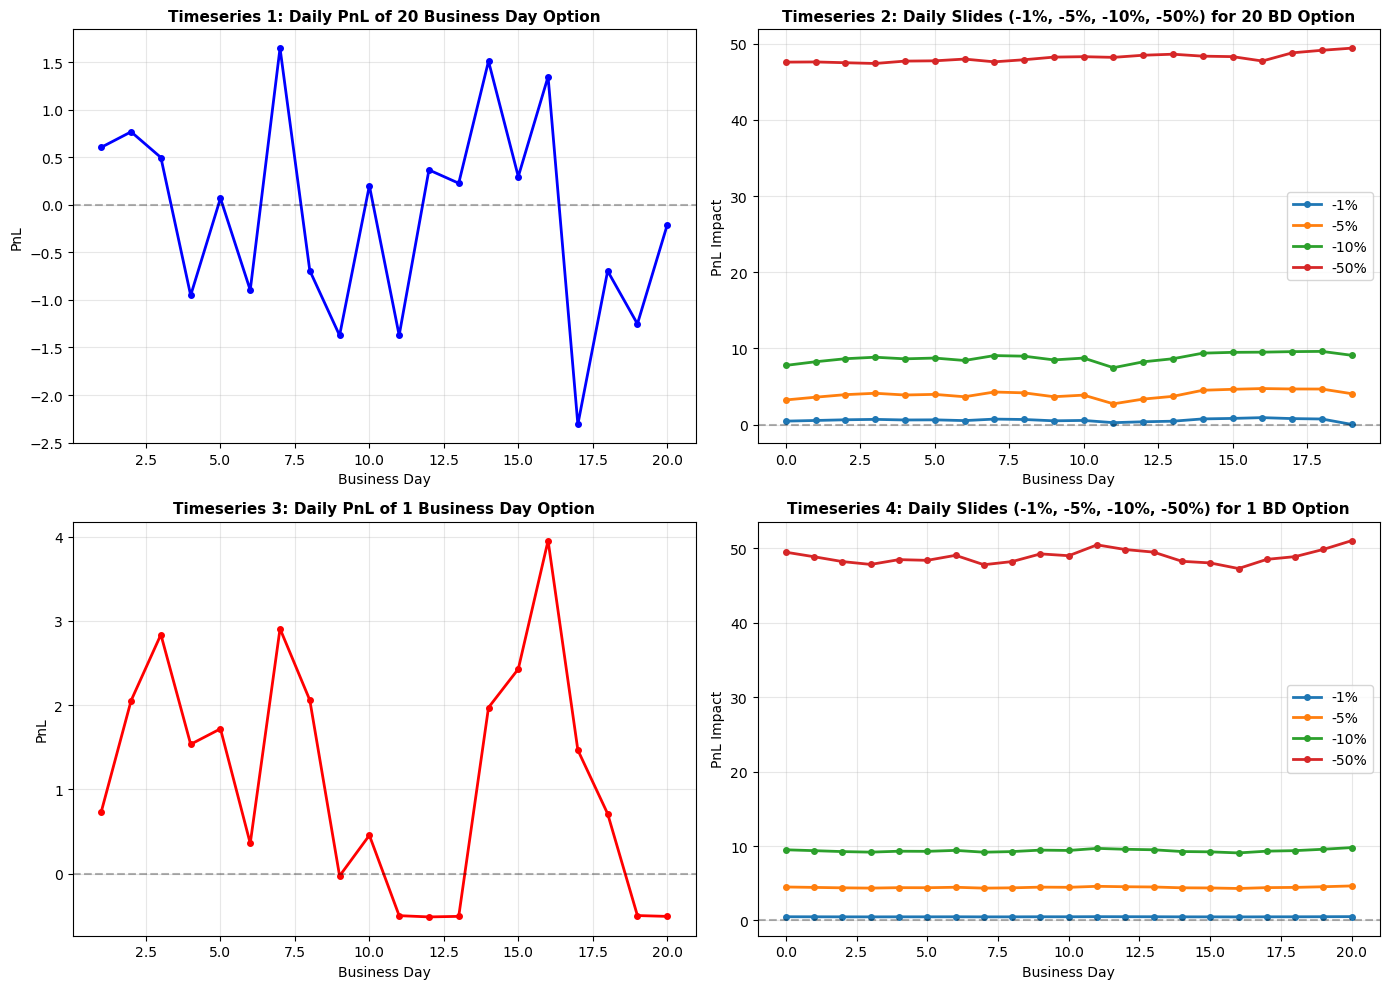


✓ All 4 timeseries have been computed successfully!


In [227]:
# ===== Summary and Visualization =====
print("\n" + "="*80)
print("SUMMARY: All 4 Timeseries Computed Successfully")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: 20 BD Option PnL
axes[0, 0].plot(timeseries_20bd['Day'], timeseries_20bd['PnL_20BD'], 'b-o', linewidth=2, markersize=4)
axes[0, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 0].set_title('Timeseries 1: Daily PnL of 20 Business Day Option', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Business Day')
axes[0, 0].set_ylabel('PnL')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: 20 BD Option Slides
for slide in slide_scenarios:
    slide_label = f'Slide_{int(slide*100):+d}pct'
    axes[0, 1].plot(timeseries_20bd_slides['Day'], timeseries_20bd_slides[slide_label], 
                     marker='o', markersize=4, label=f'{int(slide*100):+d}%', linewidth=2)
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 1].set_title('Timeseries 2: Daily Slides (-1%, -5%, -10%, -50%) for 20 BD Option', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Business Day')
axes[0, 1].set_ylabel('PnL Impact')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: 1 BD Option PnL
axes[1, 0].plot(timeseries_1bd['Day'], timeseries_1bd['PnL_1BD'], 'r-o', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 0].set_title('Timeseries 3: Daily PnL of 1 Business Day Option', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Business Day')
axes[1, 0].set_ylabel('PnL')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: 1 BD Option Slides
for slide in slide_scenarios:
    slide_label = f'Slide_{int(slide*100):+d}pct'
    axes[1, 1].plot(timeseries_1bd_slides['Day'], timeseries_1bd_slides[slide_label], 
                     marker='o', markersize=4, label=f'{int(slide*100):+d}%', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Timeseries 4: Daily Slides (-1%, -5%, -10%, -50%) for 1 BD Option', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Business Day')
axes[1, 1].set_ylabel('PnL Impact')
axes[1, 1].legend(loc='best')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ All 4 timeseries have been computed successfully!")

In [228]:
df_bt = pd.concat([timeseries_20bd, timeseries_1bd.iloc[:, 3:]], axis=1) 

In [229]:
df_bt['PnL_20BD_AJUSTED'] - df_bt['PnL_1BD']

0          NaN
1     0.098984
2    -1.110835
3    -2.285403
4    -2.541216
5    -1.642350
6    -1.352391
7    -0.904319
8    -2.761989
9    -1.415121
10   -0.211078
11   -1.078570
12    1.212961
13    0.810961
14   -0.147111
15   -2.133669
16   -2.612807
17   -3.755386
18   -1.404754
19   -0.750247
20   -2.495197
dtype: float64

In [230]:
(df_bt['PnL_20BD_AJUSTED'] - df_bt['PnL_1BD']).sum()

-26.479538763761852

In [231]:
df_bt

,Day,Time (Years),Spot Price,Option_Price_20BD,PnL_20BD,PnL_20BD_AJUSTED,Option_Price_20BD_AJUSTED,Option_Price_1BD,PnL_1BD,Option_Price_1BD_AJUSTED
0,0,0.000000,100.000000,2.238587,NaN,NaN,3.102184,0.502517,NaN,10.050340
1,1,0.003968,98.759864,2.842293,0.603706,0.836602,3.499734,0.496285,0.737619,9.429417
2,2,0.007937,97.449411,3.608526,0.766234,0.943468,4.013418,0.489700,2.054304,8.814597
3,3,0.011905,96.672992,4.104754,0.496227,0.551906,4.331347,0.485798,2.837308,8.258570
4,4,0.015873,97.978543,3.151801,-0.952952,-1.005558,3.565466,0.492359,1.535659,7.877741
5,5,0.019841,97.788314,3.219847,0.068046,0.076977,3.561149,0.491403,1.719327,7.371043
6,6,0.023810,99.149067,2.322142,-0.897705,-0.992862,2.825973,0.498241,0.359530,6.975373
7,7,0.027778,96.594657,3.967856,1.645715,2.002783,4.021780,0.485405,2.907102,6.310259
8,8,0.031746,97.454954,3.274926,-0.692931,-0.702348,3.435754,0.489728,2.059642,5.876732
9,9,0.035714,99.536897,1.900668,-1.374257,-1.441746,2.319047,0.500190,-0.026625,5.502088


In [232]:
timeseries_20bd_slides

,Day,Time (Years),Spot Price,Slide_-1pct,Slide_-5pct,Slide_-10pct,Slide_-50pct
0,0,0.000000,100.000000,0.467225,3.245457,7.778439,47.573276
1,1,0.003968,98.759864,0.552363,3.607313,8.258415,47.597311
2,2,0.007937,97.449411,0.642420,3.940617,8.654570,47.494107
3,3,0.011905,96.672992,0.695779,4.120395,8.852414,47.395000
4,4,0.015873,97.978543,0.616875,3.895319,8.639561,47.707335
5,5,0.019841,97.788314,0.635591,3.976506,8.741941,47.744232
6,6,0.023810,99.149067,0.535407,3.664198,8.424342,47.973426
7,7,0.027778,96.594657,0.731714,4.286080,9.066613,47.611860
8,8,0.031746,97.454954,0.681295,4.177850,8.989728,47.885815
9,9,0.035714,99.536897,0.507576,3.669023,8.498738,48.231316


In [233]:
slide_ratio

,Slide_-1pct,Slide_-5pct,Slide_-10pct,Slide_-50pct
0,1.064761,1.385778,1.221001,1.040447
1,0.889475,1.231307,1.135775,1.027025
2,0.754637,1.112204,1.069405,1.015600
3,0.691213,1.055203,1.037175,1.009615
4,0.790154,1.131247,1.077080,1.016550
5,0.765398,1.105999,1.062399,1.013793
6,0.921262,1.216968,1.117792,1.022989
7,0.656734,1.013590,1.011851,1.004202
8,0.711618,1.049109,1.029594,1.007349
9,0.975577,1.220122,1.112342,1.021499
